In [ ]:
import pandas as pd

# Menggunakan data berita yang telah dimuat sebelumnya
url = 'https://raw.githubusercontent.com/ach-Ilhamf/data_csv/main/data-berita.csv'
df = pd.read_csv(url)


In [ ]:
# Ringkasan statistik deskriptif
summary_stats = df.describe(include='all')
print(summary_stats)

# Info mengenai dataset
df.info()


                                                    Judul  \
count                                                 468   
unique                                                462   
top     Apakah Singkong Bagus untuk Diabetes? Ini Penj...   
freq                                                    2   

                                   Tanggal  \
count                                  468   
unique                                 409   
top     Kompas.com - 13/05/2024, 05:00 WIB   
freq                                     4   

                                                      URL  \
count                                                 468   
unique                                                462   
top     https://health.kompas.com/read/24E12180000068/...   
freq                                                    2   

                                                  Content     Kelas  
count                                                 468       468  
unique           

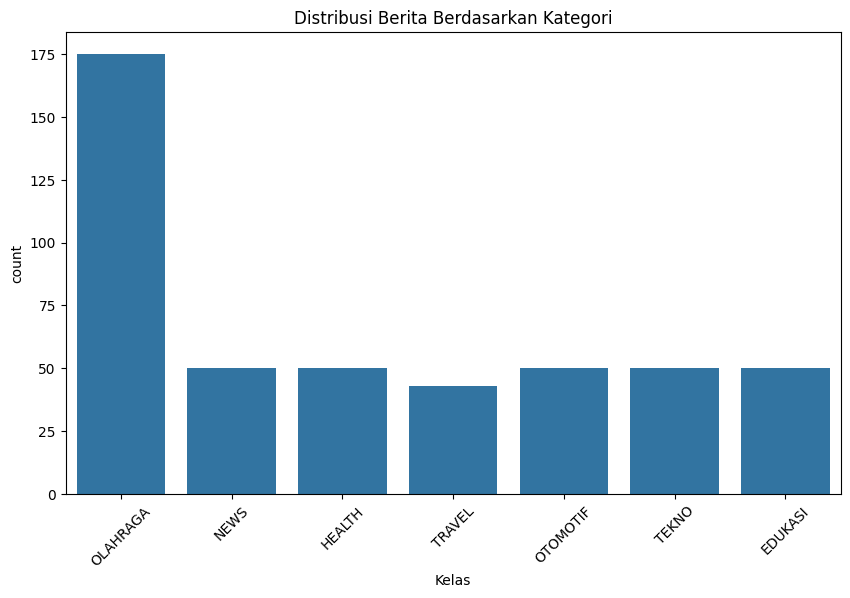

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualisasi distribusi kategori
plt.figure(figsize=(10, 6))
sns.countplot(x='Kelas', data=df)
plt.title('Distribusi Berita Berdasarkan Kategori')
plt.xticks(rotation=45)
plt.show()


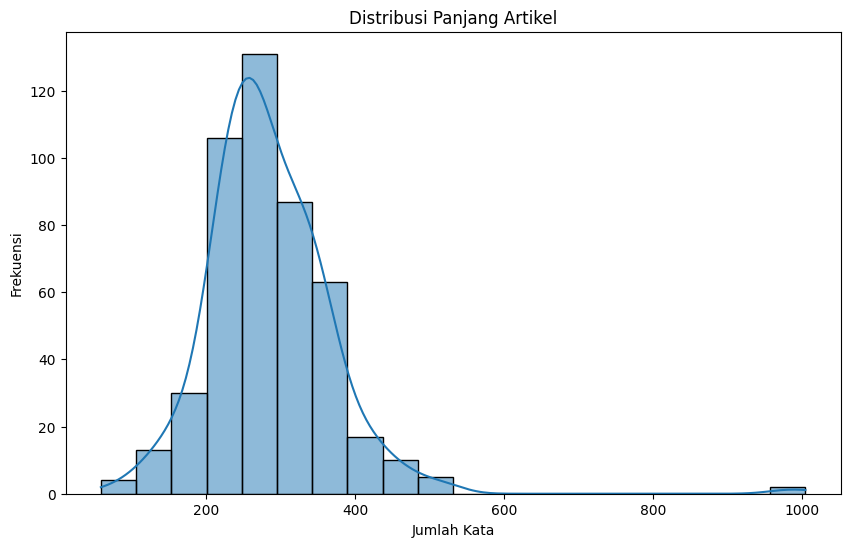

In [ ]:
# Menambahkan kolom untuk panjang artikel
df['Length'] = df['Content'].apply(lambda x: len(x.split()))

# Visualisasi distribusi panjang artikel
plt.figure(figsize=(10, 6))
sns.histplot(df['Length'], bins=20, kde=True)
plt.title('Distribusi Panjang Artikel')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.show()


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


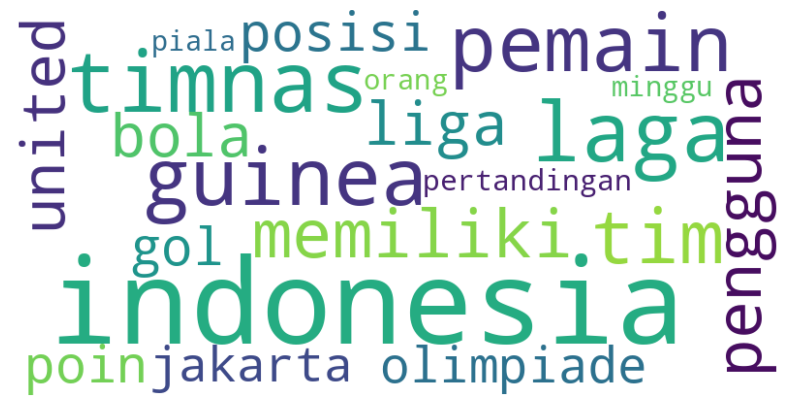

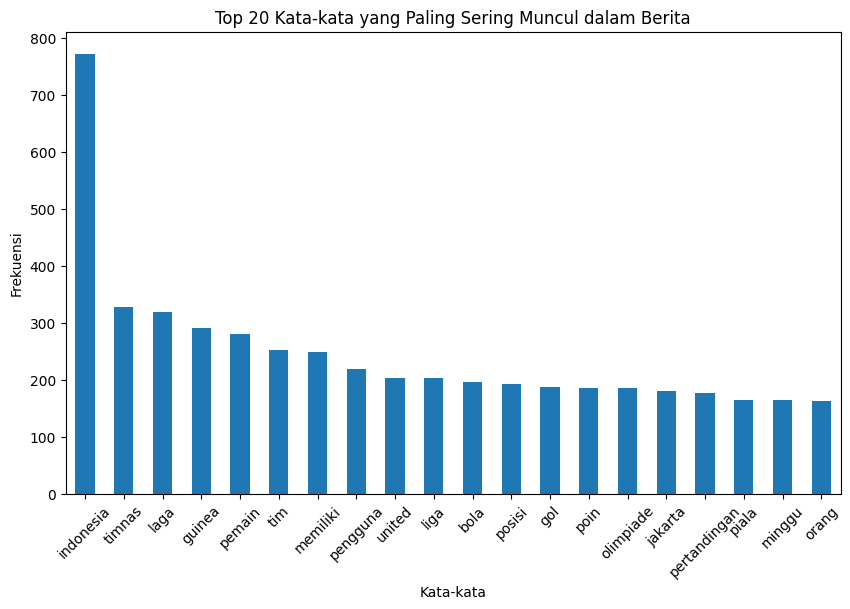

In [ ]:
import pandas as pd
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re
import nltk

# Menggunakan data berita yang telah dimuat sebelumnya
url = 'https://raw.githubusercontent.com/ach-Ilhamf/data_csv/main/data-berita.csv'
df = pd.read_csv(url)

nltk.download("punkt")
nltk.download("stopwords")

# Preprocessing teks
def preprocess_text(text):
    # Menghapus karakter khusus dan angka
    text = text.replace('\n', ' ').replace('\r', '').replace('\t', ' ')
    text = ''.join([i for i in text if not i.isdigit()])
    text = re.sub(r'[^\w\s]', '', text)

    # Mengubah teks menjadi lowercase
    text = text.lower()

    # Menghapus stopwords
    stop_words = set(stopwords.words('indonesian'))
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]

    return ' '.join(filtered_words)

# Memproses teks berita
df['Cleaned_Content'] = df['Content'].apply(preprocess_text)

# Menggabungkan semua teks menjadi satu dokumen
all_text = ' '.join(df['Cleaned_Content'].values)

# Menghitung frekuensi kata-kata
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['Cleaned_Content'])

# Kata-kata yang paling sering muncul
word_frequencies = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
top_words = word_frequencies.sum().sort_values(ascending=False).head(20)

# Visualisasi menggunakan word cloud
plt.figure(figsize=(10, 8))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(top_words)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()
print("\n")
# Visualisasi menggunakan plot bar
plt.figure(figsize=(10, 6))
top_words.plot(kind='bar')
plt.title('Top 20 Kata-kata yang Paling Sering Muncul dalam Berita')
plt.xlabel('Kata-kata')
plt.ylabel('Frekuensi')
plt.xticks(rotation=45)
plt.show()
